## Stage 5 — Highlight Detection, Phase 1: Geometric Filter

##What the Geometric Filter does

Before any learning, we use pure math on the embeddings to find segments that are "interesting" — no training required. The idea: a highlight is a moment where all 3 modalities agree strongly AND the segment is locally different from its neighbors.

##The 3 geometric signals we compute

    Signal 1: Cross-modal Coherence
    How well do vision, audio, and text agree with each other?
    High coherence = all modalities tell the same story = meaningful moment

    Signal 2: Local Novelty
    How different is this segment from the ones around it?
    High novelty = something changed = potential highlight boundary

    Signal 3: Temporal Saliency
    How different is this segment from the global video average?
    High saliency = this moment stands out from the whole video

---



In [5]:
# ── CELL 1: Mount Drive & Configure Paths ────────────────────────────────
import sys, os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT   = "/content/drive/MyDrive/PFA"
IMAGEBIND_ROOT = "/content/drive/MyDrive/PFA/ImageBind"
LIB_ROOT       = "/content/drive/MyDrive/PFA/ImageBind/ImageBind"

for p in [LIB_ROOT, IMAGEBIND_ROOT, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

INPUT_DIR  = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(IMAGEBIND_ROOT, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_VIDEO = "Obama_Yes_we_can.mp4"
VIDEO_PATH   = os.path.join(INPUT_DIR, TARGET_VIDEO)
VIDEO_STEM   = os.path.splitext(TARGET_VIDEO)[0]

TEXTS_PATH   = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_segment_texts.json")
EMB_PATH     = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_embeddings_final.npz")

print(f"Input : {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Mounted at /content/drive
Input : /content/drive/MyDrive/PFA/data
Output: /content/drive/MyDrive/PFA/ImageBind/results


In [6]:
# ── CELL 12: Load Stage 4 output ─────────────────────────────────────────
import numpy as np
import torch
import torch.nn.functional as F

UNIFIED_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_unified_final.npz")

npz     = np.load(UNIFIED_PATH, allow_pickle=True)
unified = torch.tensor(npz['unified'])        # [88, 512]
times   = npz['times']                        # [88, 2]
texts   = npz['raw_text']                     # [88]
trust   = torch.tensor(npz['text_trust'])     # [88]

# Also reload per-modality embeddings for coherence computation
emb_npz = np.load(EMB_PATH, allow_pickle=True)
V = F.normalize(torch.tensor(emb_npz['vision']), dim=-1)   # [88, 1024]
A = F.normalize(torch.tensor(emb_npz['audio']),  dim=-1)   # [88, 1024]
T = F.normalize(torch.tensor(emb_npz['text']),   dim=-1)   # [88, 1024]

print(f"unified : {unified.shape}")
print(f"V/A/T   : {V.shape}")
print(f"Segments: {len(times)}")

unified : torch.Size([88, 512])
V/A/T   : torch.Size([88, 1024])
Segments: 88


In [17]:
# ── CELL 13: Geometric Signal Computation ────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np

def compute_crossmodal_coherence(V, A, T, text_trust):
    """
    Per-segment cosine similarity across all 3 modality pairs.
    text_trust downweights text contribution for non-speech segments.
    """
    va = (V * A).sum(dim=-1)                        # [N]
    vt = (V * T).sum(dim=-1) * text_trust           # [N]
    at = (A * T).sum(dim=-1) * text_trust           # [N]

    # weighted average — text pairs count less when trust is low
    w_va = torch.ones_like(va)
    w_vt = text_trust
    w_at = text_trust

    coherence = (w_va * va + w_vt * vt + w_at * at) / (w_va + w_vt + w_at + 1e-8)
    return coherence                                 # [N]  range ~ [-1, 1]


def compute_local_novelty(unified, window=5):
    """
    How different is each segment from its local neighborhood?
    window: how many neighbors on each side to compare against.
    """
    N = len(unified)
    novelty = torch.zeros(N)

    for i in range(N):
        lo = max(0, i - window)
        hi = min(N, i + window + 1)

        # neighbors excluding self
        neighbors = torch.cat([unified[lo:i], unified[i+1:hi]], dim=0)

        if len(neighbors) == 0:
            novelty[i] = 0.0
            continue

        local_mean = neighbors.mean(dim=0)
        local_mean = F.normalize(local_mean.unsqueeze(0), dim=-1).squeeze(0)
        seg_norm   = F.normalize(unified[i].unsqueeze(0), dim=-1).squeeze(0)

        # 1 - cosine_sim → high value = very different from neighbors
        novelty[i] = 1.0 - (seg_norm * local_mean).sum()

    return novelty                                   # [N]  range ~ [0, 2]


def compute_temporal_saliency(unified):
    """
    How different is each segment from the global video mean?
    Highlights should deviate from the average more than filler content.
    """
    global_mean = unified.mean(dim=0)
    global_mean = F.normalize(global_mean.unsqueeze(0), dim=-1).squeeze(0)
    unified_norm = F.normalize(unified, dim=-1)

    saliency = 1.0 - (unified_norm * global_mean).sum(dim=-1)
    return saliency                                  # [N]  range ~ [0, 2]


# ── Run all 3 ──
coherence = compute_crossmodal_coherence(V, A, T, trust)
novelty   = compute_local_novelty(unified, window=5)
saliency  = compute_temporal_saliency(unified)

print("Signal stats (mean ± std):")
print(f"  Coherence : {coherence.mean():.3f} ± {coherence.std():.3f}  "
      f"min={coherence.min():.3f}  max={coherence.max():.3f}")
print(f"  Novelty   : {novelty.mean():.3f} ± {novelty.std():.3f}  "
      f"min={novelty.min():.3f}  max={novelty.max():.3f}")
print(f"  Saliency  : {saliency.mean():.3f} ± {saliency.std():.3f}  "
      f"min={saliency.min():.3f}  max={saliency.max():.3f}")

Signal stats (mean ± std):
  Coherence : 0.258 ± 0.039  min=0.154  max=0.346
  Novelty   : 0.082 ± 0.028  min=0.034  max=0.201
  Saliency  : 0.085 ± 0.024  min=0.053  max=0.202


In [18]:
# ── CELL 14: Combine Signals → Geometric Score ───────────────────────────

def minmax_normalize(x):
    """Scale tensor to [0, 1]."""
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# Normalize each signal to [0, 1]
coherence_n = minmax_normalize(coherence)
novelty_n   = minmax_normalize(novelty)
saliency_n  = minmax_normalize(saliency)

# Weighted combination — coherence matters most
# (a highlight needs modal agreement more than pure novelty)
W_COHERENCE = 0.5
W_NOVELTY   = 0.3
W_SALIENCY  = 0.2

geo_score = (
    W_COHERENCE * coherence_n +
    W_NOVELTY   * novelty_n   +
    W_SALIENCY  * saliency_n
)

print("Geometric score stats:")
print(f"  mean={geo_score.mean():.3f}  std={geo_score.std():.3f}  "
      f"min={geo_score.min():.3f}  max={geo_score.max():.3f}")

# Top 10 segments by score
top10_idx = geo_score.argsort(descending=True)[:10]
print(f"\nTop 10 segments:")
for rank, idx in enumerate(top10_idx):
    i = idx.item()
    print(f"  #{rank+1:>2}  [{times[i][0]:.1f}s → {times[i][1]:.1f}s]  "
          f"score={geo_score[i]:.3f}  "
          f"coh={coherence_n[i]:.2f}  nov={novelty_n[i]:.2f}  sal={saliency_n[i]:.2f}  "
          f"| {texts[i][:50]}")

Geometric score stats:
  mean=0.401  std=0.082  min=0.249  max=0.616

Top 10 segments:
  # 1  [27.0s → 29.0s]  score=0.616  coh=1.00  nov=0.23  sal=0.23  | I don't ask of you as your President.
  # 2  [15.0s → 17.0s]  score=0.565  coh=0.88  nov=0.30  sal=0.18  | a citizen.
  # 3  [60.0s → 62.0s]  score=0.551  coh=0.74  nov=0.42  sal=0.28  | reaffirmed by those who...
  # 4  [46.0s → 48.0s]  score=0.535  coh=0.91  nov=0.17  sal=0.14  | written in to our founding documents.
  # 5  [53.0s → 55.0s]  score=0.529  coh=0.72  nov=0.38  sal=0.29  | spirit sung by Amigrants.
  # 6  [8.0s → 10.0s]  score=0.523  coh=0.75  nov=0.35  sal=0.22  | life to serve you.
  # 7  [28.0s → 30.0s]  score=0.519  coh=0.90  nov=0.19  sal=0.07  | as your President.
  # 8  [14.0s → 16.0s]  score=0.515  coh=0.84  nov=0.26  sal=0.10  | with you as a citizen.
  # 9  [19.0s → 21.0s]  score=0.506  coh=0.67  nov=0.37  sal=0.30  | the remaining days.
  #10  [5.0s → 7.0s]  score=0.505  coh=0.46  nov=0.56  sal=0.52  | It ha

In [19]:
# ── CELL 15: Save Geometric Filter Output ────────────────────────────────
GEO_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_geo_scores.npz")

np.savez(GEO_PATH,
         geo_score=geo_score.numpy(),
         coherence=coherence_n.numpy(),
         novelty=novelty_n.numpy(),
         saliency=saliency_n.numpy(),
         times=times,
         raw_text=texts
)

print(f"✓ Saved geometric scores → {GEO_PATH}")

✓ Saved geometric scores → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_geo_scores.npz


In [20]:
# ── CELL 16: Save Top 20 Segments ────────────────────────────────────────

TOP_N = 20
top_idx = geo_score.argsort(descending=True)[:TOP_N]

top_scores     = geo_score[top_idx].numpy()
top_coherence  = coherence_n[top_idx].numpy()
top_novelty    = novelty_n[top_idx].numpy()
top_saliency   = saliency_n[top_idx].numpy()
top_times      = np.array([times[i.item()] for i in top_idx])
top_texts      = np.array([texts[i.item()] for i in top_idx])
top_ranks      = np.arange(1, TOP_N + 1)

TOP_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_top{TOP_N}_segments.npz")

np.savez(
    TOP_PATH,
    rank=top_ranks,
    geo_score=top_scores,
    coherence=top_coherence,
    novelty=top_novelty,
    saliency=top_saliency,
    times=top_times,       # shape (20, 2) — [start_s, end_s]
    raw_text=top_texts,
)

print(f"✓ Saved top {TOP_N} segments → {TOP_PATH}")
print(f"\n{'Rank':<6} {'Start':>7} {'End':>7} {'Score':>7} {'Coh':>6} {'Nov':>6} {'Sal':>6}  Text")
print("─" * 90)
for r, idx in enumerate(top_idx):
    i = idx.item()
    print(f"  #{r+1:<4} {times[i][0]:>6.1f}s {times[i][1]:>6.1f}s "
          f"{geo_score[i]:>7.3f} {coherence_n[i]:>6.2f} {novelty_n[i]:>6.2f} {saliency_n[i]:>6.2f}"
          f"  {texts[i][:45]}")

✓ Saved top 20 segments → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_top20_segments.npz

Rank     Start     End   Score    Coh    Nov    Sal  Text
──────────────────────────────────────────────────────────────────────────────────────────
  #1      27.0s   29.0s   0.616   1.00   0.23   0.23  I don't ask of you as your President.
  #2      15.0s   17.0s   0.565   0.88   0.30   0.18  a citizen.
  #3      60.0s   62.0s   0.551   0.74   0.42   0.28  reaffirmed by those who...
  #4      46.0s   48.0s   0.535   0.91   0.17   0.14  written in to our founding documents.
  #5      53.0s   55.0s   0.529   0.72   0.38   0.29  spirit sung by Amigrants.
  #6       8.0s   10.0s   0.523   0.75   0.35   0.22  life to serve you.
  #7      28.0s   30.0s   0.519   0.90   0.19   0.07  as your President.
  #8      14.0s   16.0s   0.515   0.84   0.26   0.10  with you as a citizen.
  #9      19.0s   21.0s   0.506   0.67   0.37   0.30  the remaining days.
  #10      5.0s    7.0s   0.505   0.

## some plots

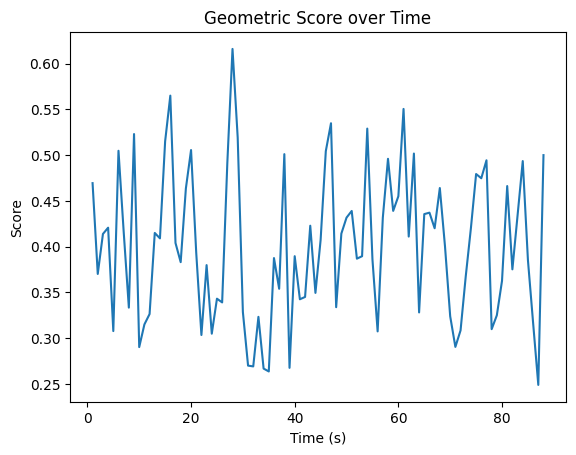

In [ ]:
import matplotlib.pyplot as plt

geo = np.load(GEO_PATH)
scores = geo['geo_score']
times = geo['times']

mid_times = (times[:,0] + times[:,1]) / 2

plt.figure()
plt.plot(mid_times, scores)
plt.title("Geometric Score over Time")
plt.xlabel("Time (s)")
plt.ylabel("Score")
plt.show()

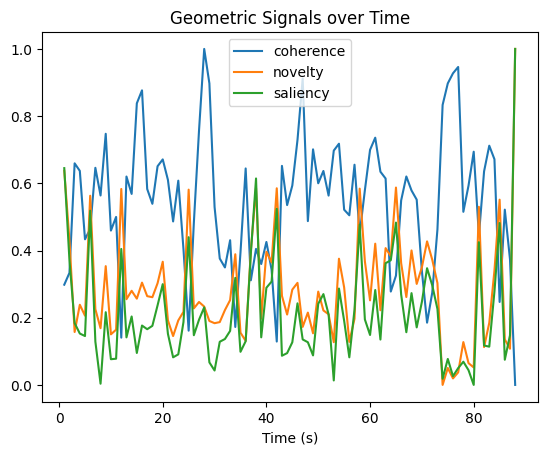

In [ ]:
plt.figure()
plt.plot(mid_times, geo['coherence'], label="coherence")
plt.plot(mid_times, geo['novelty'], label="novelty")
plt.plot(mid_times, geo['saliency'], label="saliency")
plt.legend()
plt.title("Geometric Signals over Time")
plt.xlabel("Time (s)")
plt.show()

In [ ]:
topk = np.argsort(scores)[::-1][:10]

for i in topk:
    print(f"{times[i]} | score={scores[i]:.3f} | {geo['raw_text'][i]}")

[27. 29.] | score=0.616 | I don't ask of you as your President.
[15. 17.] | score=0.565 | a citizen.
[60. 62.] | score=0.551 | reaffirmed by those who...
[46. 48.] | score=0.535 | written in to our founding documents.
[53. 55.] | score=0.529 | spirit sung by Amigrants.
[ 8. 10.] | score=0.523 | life to serve you.
[28. 30.] | score=0.519 | as your President.
[14. 16.] | score=0.515 | with you as a citizen.
[19. 21.] | score=0.506 | the remaining days.
[5. 7.] | score=0.505 | It has been


In [ ]:
import sys, os
from google.colab import drive
import numpy as np
import torch

drive.mount('/content/drive')

PROJECT_ROOT   = "/content/drive/MyDrive/PFA"
IMAGEBIND_ROOT = "/content/drive/MyDrive/PFA/ImageBind"
LIB_ROOT       = "/content/drive/MyDrive/PFA/ImageBind/ImageBind"

TARGET_VIDEO = "Obama_Yes_we_can.mp4"
VIDEO_PATH   = os.path.join(INPUT_DIR, TARGET_VIDEO)
VIDEO_STEM   = os.path.splitext(TARGET_VIDEO)[0]


INPUT_DIR  = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(IMAGEBIND_ROOT, "results")

GEO_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_embeddings_final.npz")
geo = np.load(GEO_PATH)


V = torch.tensor(geo['vision'])
A = torch.tensor(geo['audio'])
T = torch.tensor(geo['text'])

print("VISION NON-ZERO:", V.abs().sum())
print("AUDIO NON-ZERO:", A.abs().sum())
print("TEXT NON-ZERO:", T.abs().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VISION NON-ZERO: tensor(2024.5862)
AUDIO NON-ZERO: tensor(2199.6289)
TEXT NON-ZERO: tensor(1891.6825)


In [ ]:
print("\nPer-modality stats:")

for name, X in zip(["Vision", "Audio", "Text"], [V, A, T]):
    print(f"{name}:")
    print("  sum:", X.abs().sum().item())
    print("  mean:", X.mean().item())
    print("  std:", X.std().item())
    print("  min:", X.min().item())
    print("  max:", X.max().item())


Per-modality stats:
Vision:
  sum: 2024.586181640625
  mean: -0.0011878276709467173
  std: 0.031227590516209602
  min: -0.35592830181121826
  max: 0.40558165311813354
Audio:
  sum: 2199.62890625
  mean: -0.0008211670792661607
  std: 0.031239382922649384
  min: -0.17406830191612244
  max: 0.15426307916641235
Text:
  sum: 1891.6824951171875
  mean: -0.0005170084186829627
  std: 0.031245896592736244
  min: -0.4915321469306946
  max: 0.4883178472518921


## Inhancement:
using window: a scene = 2 segments

In [8]:
# ── CELL 13b: Pairwise Window Signals ────────────────────────────────────
# A "scene" = 2 consecutive segments scored together relative to their
# joint neighborhood. This avoids rating each segment in isolation.

import torch
import torch.nn.functional as F
import numpy as np

WINDOW = 5   # neighbors on each side (excluding the pair itself)

def compute_pairwise_coherence(V, A, T, trust, window=5):
    """
    Score each consecutive pair (i, i+1) by the average cross-modal
    coherence of the two segments, using only their joint neighborhood
    as context (not the pair itself).
    Returns seg_scores [N] and pair_scores [N-1].
    """
    N = V.shape[0]
    pair_scores = torch.zeros(N - 1)

    for i in range(N - 1):
        j = i + 1

        # indices of the joint neighborhood (exclude i and j)
        lo = max(0,     i - window)
        hi = min(N,     j + window + 1)
        ctx_idx = [k for k in range(lo, hi) if k != i and k != j]

        if len(ctx_idx) == 0:
            # edge case: no neighbors at all
            pair_scores[i] = 0.0
            continue

        # ── coherence of each segment in the pair ──────────────────────
        def seg_coherence(idx):
            w_t = trust[idx]
            va  = (V[idx] * A[idx]).sum()
            vt  = (V[idx] * T[idx]).sum() * w_t
            at  = (A[idx] * T[idx]).sum() * w_t
            denom = 1.0 + w_t + w_t + 1e-8
            return (va + vt + at) / denom

        coh_i = seg_coherence(i)
        coh_j = seg_coherence(j)

        # ── neighborhood mean coherence (context baseline) ─────────────
        ctx_coh = torch.stack([seg_coherence(k) for k in ctx_idx]).mean()

        # pair score = how much the pair exceeds its neighborhood baseline
        pair_scores[i] = ((coh_i + coh_j) / 2.0) - ctx_coh

    # attribute pair score back to both members equally
    seg_scores = torch.zeros(N)
    for i in range(N - 1):
        seg_scores[i]   += pair_scores[i] * 0.5
        seg_scores[i+1] += pair_scores[i] * 0.5

    return seg_scores, pair_scores


def compute_pairwise_novelty(unified, window=5):
    """
    Score each consecutive pair (i, i+1) by how much they diverge
    from each other relative to their joint neighborhood context.

    - direct_divergence  : how different are i and j from each other?
    - context_divergence : how different are their left/right contexts?

    Both must be high → clean boundary between two distinct scenes.
    Returns seg_scores [N] and pair_scores [N-1].
    """
    N = len(unified)
    pair_scores = torch.zeros(N - 1)

    for i in range(N - 1):
        j = i + 1

        # left context  = neighbors of i, before the pair
        lo_i     = max(0, i - window)
        left_ctx = unified[lo_i:i]

        # right context = neighbors of j, after the pair
        hi_j      = min(N, j + window + 1)
        right_ctx = unified[j+1:hi_j]

        ctx_i = left_ctx.mean(dim=0)  if len(left_ctx)  > 0 else unified[i]
        ctx_j = right_ctx.mean(dim=0) if len(right_ctx) > 0 else unified[j]

        ctx_i = F.normalize(ctx_i.unsqueeze(0), dim=-1).squeeze(0)
        ctx_j = F.normalize(ctx_j.unsqueeze(0), dim=-1).squeeze(0)

        si = F.normalize(unified[i].unsqueeze(0), dim=-1).squeeze(0)
        sj = F.normalize(unified[j].unsqueeze(0), dim=-1).squeeze(0)

        direct_divergence  = 1.0 - (si  * sj ).sum()   # pair differ?
        context_divergence = 1.0 - (ctx_i * ctx_j).sum()  # contexts differ?

        pair_scores[i] = 0.6 * direct_divergence + 0.4 * context_divergence

    seg_scores = torch.zeros(N)
    for i in range(N - 1):
        seg_scores[i]   += pair_scores[i] * 0.5
        seg_scores[i+1] += pair_scores[i] * 0.5

    return seg_scores, pair_scores


def compute_pairwise_saliency(unified, window=5):
    """
    Score each consecutive pair (i, i+1) by how much the pair's mean
    deviates from the global video mean — but using only the joint
    neighborhood to estimate the local baseline instead of the full video.
    Returns seg_scores [N] and pair_scores [N-1].
    """
    N = len(unified)
    global_mean = F.normalize(unified.mean(dim=0).unsqueeze(0), dim=-1).squeeze(0)
    pair_scores  = torch.zeros(N - 1)

    for i in range(N - 1):
        j = i + 1

        lo = max(0,  i - window)
        hi = min(N,  j + window + 1)
        ctx_idx = [k for k in range(lo, hi) if k != i and k != j]

        pair_mean = F.normalize(
            ((unified[i] + unified[j]) / 2.0).unsqueeze(0), dim=-1
        ).squeeze(0)

        # deviation from global
        global_dev = 1.0 - (pair_mean * global_mean).sum()

        # deviation from local neighborhood baseline
        if len(ctx_idx) > 0:
            local_mean = F.normalize(
                unified[ctx_idx].mean(dim=0).unsqueeze(0), dim=-1
            ).squeeze(0)
            local_dev = 1.0 - (pair_mean * local_mean).sum()
        else:
            local_dev = global_dev

        # a highlight should stand out both locally AND globally
        pair_scores[i] = 0.5 * global_dev + 0.5 * local_dev

    seg_scores = torch.zeros(N)
    for i in range(N - 1):
        seg_scores[i]   += pair_scores[i] * 0.5
        seg_scores[i+1] += pair_scores[i] * 0.5

    return seg_scores, pair_scores



In [9]:

# ── Run all 3 pairwise signals ────────────────────────────────────────────
pw_coherence, pw_coh_pairs = compute_pairwise_coherence(V, A, T, trust, WINDOW)
pw_novelty,   pw_nov_pairs = compute_pairwise_novelty(unified, WINDOW)
pw_saliency,  pw_sal_pairs = compute_pairwise_saliency(unified, WINDOW)

print("Pairwise signal stats (mean ± std):")
for name, s in [("Coherence", pw_coherence), ("Novelty", pw_novelty), ("Saliency", pw_saliency)]:
    print(f"  {name:<12}: {s.mean():.3f} ± {s.std():.3f}  "
          f"min={s.min():.3f}  max={s.max():.3f}")

Pairwise signal stats (mean ± std):
  Coherence   : -0.000 ± 0.032  min=-0.075  max=0.089
  Novelty     : 0.090 ± 0.022  min=0.043  max=0.156
  Saliency    : 0.059 ± 0.010  min=0.036  max=0.083


In [13]:
# ── CELL 14b: Combine Pairwise Signals → Geo Score ───────────────────────
# Score lives on pairs [N-1], not segments [N]

def minmax_normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

pw_coherence_n = minmax_normalize(pw_coh_pairs)   # [N-1]
pw_novelty_n   = minmax_normalize(pw_nov_pairs)   # [N-1]
pw_saliency_n  = minmax_normalize(pw_sal_pairs)   # [N-1]

W_COHERENCE = 0.5
W_NOVELTY   = 0.3
W_SALIENCY  = 0.2

geo_score_pairs = (
    W_COHERENCE * pw_coherence_n +
    W_NOVELTY   * pw_novelty_n   +
    W_SALIENCY  * pw_saliency_n
)   # [N-1]

print("Pair geo score stats:")
print(f"  mean={geo_score_pairs.mean():.3f}  std={geo_score_pairs.std():.3f}  "
      f"min={geo_score_pairs.min():.3f}  max={geo_score_pairs.max():.3f}")

# Top 10 pairs preview
top10_pair_idx = geo_score_pairs.argsort(descending=True)[:10]
print(f"\nTop 10 pairs  (i, i+1):")
print(f"  {'Rank':<5} {'Seg i':>6} {'Seg j':>6}  {'Start':>7} {'End':>7}  "
      f"{'Score':>7} {'Coh':>6} {'Nov':>6} {'Sal':>6}  Text i | Text j")
print("─" * 110)
for rank, pidx in enumerate(top10_pair_idx):
    p = pidx.item()
    i, j = p, p + 1
    t_start = times[i][0]
    t_end   = times[j][1]
    print(f"  #{rank+1:<4} [{i:>3}]  [{j:>3}]  "
          f"{t_start:>6.1f}s {t_end:>6.1f}s  "
          f"{geo_score_pairs[p]:>7.3f} {pw_coherence_n[p]:>6.2f} "
          f"{pw_novelty_n[p]:>6.2f} {pw_saliency_n[p]:>6.2f}  "
          f"{texts[i][:30]} | {texts[j][:30]}")

Pair geo score stats:
  mean=0.416  std=0.088  min=0.237  max=0.631

Top 10 pairs  (i, i+1):
  Rank   Seg i  Seg j    Start     End    Score    Coh    Nov    Sal  Text i | Text j
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  #1    [ 27]  [ 28]    27.0s   30.0s    0.631   1.00   0.15   0.44  I don't ask of you as your Pre | as your President.
  #2    [ 36]  [ 37]    36.0s   39.0s    0.601   0.57   0.65   0.60  You to believe | Speech, Male speech, man speak
  #3    [ 26]  [ 27]    26.0s   29.0s    0.601   0.88   0.33   0.31  I do have one final ask of you | I don't ask of you as your Pre
  #4    [ 86]  [ 87]    86.0s   89.0s    0.559   0.17   1.00   0.86  Thank you. | Applause. a close up of a pers
  #5    [ 14]  [ 15]    14.0s   17.0s    0.553   0.79   0.22   0.46  with you as a citizen. | a citizen.
  #6    [  1]  [  2]     1.0s    4.0s    0.547   0.51   0.83   0.20  Thank you. | My fellow men.
  #7    [  0]  [  1]    

In [14]:
# ── CELL 15b: Save Pairwise Geometric Output ─────────────────────────────
GEO_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_geo_scores_pairwise.npz")

# Build pair-level time spans: start of i → end of j
N = len(times)
pair_times = np.array([[times[p][0], times[p+1][1]] for p in range(N - 1)])  # [N-1, 2]
pair_texts = np.array([f"{texts[p]} | {texts[p+1]}" for p in range(N - 1)]) # [N-1]

np.savez(
    GEO_PATH,
    geo_score  = geo_score_pairs.numpy(),   # [N-1]
    coherence  = pw_coherence_n.numpy(),
    novelty    = pw_novelty_n.numpy(),
    saliency   = pw_saliency_n.numpy(),
    times      = pair_times,                # [N-1, 2]  start of i → end of j
    raw_text   = pair_texts,
)
print(f"✓ Saved {N-1} pair scores → {GEO_PATH}")

✓ Saved 87 pair scores → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_geo_scores_pairwise.npz


In [16]:
# ── CELL 16b: Save Top 20 Pairs ───────────────────────────────────────────
TOP_N = 20
top_pair_idx = geo_score_pairs.argsort(descending=True)[:TOP_N]

top_p = top_pair_idx.numpy()          # pair indices  e.g. 43 → segments 43+44

TOP_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_top{TOP_N}_pairs.npz")

np.savez(
    TOP_PATH,
    rank         = np.arange(1, TOP_N + 1),
    pair_idx     = top_p,                                         # [20]    which pair
    seg_i        = top_p,                                         # [20]    first segment index
    seg_j        = top_p + 1,                                     # [20]    second segment index
    geo_score    = geo_score_pairs[top_pair_idx].numpy(),         # [20]
    coherence    = pw_coherence_n[top_pair_idx].numpy(),
    novelty      = pw_novelty_n[top_pair_idx].numpy(),
    saliency     = pw_saliency_n[top_pair_idx].numpy(),
    times        = pair_times[top_p],                             # [20, 2]
    raw_text     = pair_texts[top_p],                             # [20]
)

print(f"✓ Saved top {TOP_N} pairs → {TOP_PATH}")
print(f"\n{'Rank':<6} {'Segs':>10}  {'Start':>7} {'End':>7}  "
      f"{'Score':>7} {'Coh':>6} {'Nov':>6} {'Sal':>6}  Text")
print("─" * 105)
for rank, pidx in enumerate(top_pair_idx):
    p = pidx.item()
    i, j = p, p + 1
    print(f"  #{rank+1:<4} [{i:>3} + {j:>3}]  "
          f"{times[i][0]:>6.1f}s {times[j][1]:>6.1f}s  "
          f"{geo_score_pairs[p]:>7.3f} {pw_coherence_n[p]:>6.2f} "
          f"{pw_novelty_n[p]:>6.2f} {pw_saliency_n[p]:>6.2f}  "
          f"{texts[i][:25]} | {texts[j][:25]}")

✓ Saved top 20 pairs → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_top20_pairs.npz

Rank         Segs    Start     End    Score    Coh    Nov    Sal  Text
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  #1    [ 27 +  28]    27.0s   30.0s    0.631   1.00   0.15   0.44  I don't ask of you as you | as your President.
  #2    [ 36 +  37]    36.0s   39.0s    0.601   0.57   0.65   0.60  You to believe | Speech, Male speech, man 
  #3    [ 26 +  27]    26.0s   29.0s    0.601   0.88   0.33   0.31  I do have one final ask o | I don't ask of you as you
  #4    [ 86 +  87]    86.0s   89.0s    0.559   0.17   1.00   0.86  Thank you. | Applause. a close up of a
  #5    [ 14 +  15]    14.0s   17.0s    0.553   0.79   0.22   0.46  with you as a citizen. | a citizen.
  #6    [  1 +   2]     1.0s    4.0s    0.547   0.51   0.83   0.20  Thank you. | My fellow men.
  #7    [  0 +   1]     0.0s    3.0s    0.546   0.26   0.72   1.00